In [75]:
# cuda visible 
import os 
os.environ['CUDA_VISIBLE_DEVICES'] = "1"

import torch.backends.cudnn as cudnn
cudnn.benchmark = True

In [ ]:
import os 
import torch 
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.optim import Adam
from tqdm import tqdm
import matplotlib.pyplot as plt


from torch.utils.tensorboard import SummaryWriter
import torchvision.utils as vutils

from CityScapes import CityscapesDataset

from DCGAN.discriminator import Discriminator
from DCGAN.encoder import Encoder
from DCGAN.generator import Generator
from file_management import get_version_folder, save_config, load_config
from DCGAN.loss_functions import GradientPenaltyLoss, WeightedMSELoss


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
scale_for_display = lambda x: torch.clamp((x + 1.0) / 2.0, 0.0, 1.0)


In [77]:
load_run = None
config_name = 'config.yaml'

In [78]:
if load_run:
    config_path = os.path.join(load_run,config_name)
    config = load_config(config_path)
    config['root_path'] = load_run
    
    index_folder = load_run
else:
    root = 'cache/dcgan'
    index_folder = get_version_folder(root)
    config = load_config(config_name)
    config['root_path'] =index_folder

    config_target_path = os.path.join(index_folder,config_name)
    save_config(config, config_target_path)




Config saved to cache/dcgan/2/config.yaml


In [ ]:
channels = config['models']['channels']
z_shape = config['models']['z_shape']
z_dim = z_shape[0]

enc_block_depth = config['models']['enc']['block_depth']
enc_residual = config['models']['enc']['residual']
enc_use_norm = config['models']['enc']['use_norm']

gen_block_depth = config['models']['gen']['block_depth']
gen_residual = config['models']['gen']['residual']
gen_use_norm = config['models']['gen']['use_norm']

disc_block_depth = config['models']['disc']['block_depth']
disc_residual = config['models']['disc']['residual']
disc_use_norm = config['models']['disc']['use_norm']

batch_size = config['training']['batch_size']

enc_lr = config['training']['enc']['enc_lr']
enc_reconstruction_loss_weight = config['training']['enc']['enc_reconstruction_loss_weight']


gen_lr = config['training']['gen']['gen_lr']

disc_lr = config['training']['disc']['disc_lr']
gp_weight_loss = config['training']['disc']['gp_weight_loss']
drift_weight_loss = config['training']['disc']['drift_weight_loss']



save_itter = config["training"]["save_itter"]
samples_path = os.path.join(index_folder,'samples')
os.makedirs(samples_path,exist_ok=True)

enc_path = os.path.join(index_folder,'enc.pth')
gen_path = os.path.join(index_folder,'gen.pth')
disc_path = os.path.join(index_folder,'disc.pth')


tensorboard_path = os.path.join(index_folder, 'logs')
writer = SummaryWriter(log_dir=tensorboard_path)

In [80]:

class WeightedMSELoss(nn.Module):
    def __init__(self, weight=1.0):
        super().__init__()
        self.weight = weight

    def forward(self, input, target):
        return self.weight * torch.mean((input - target) ** 2)

Text(0.5, 1.0, 'Fake')

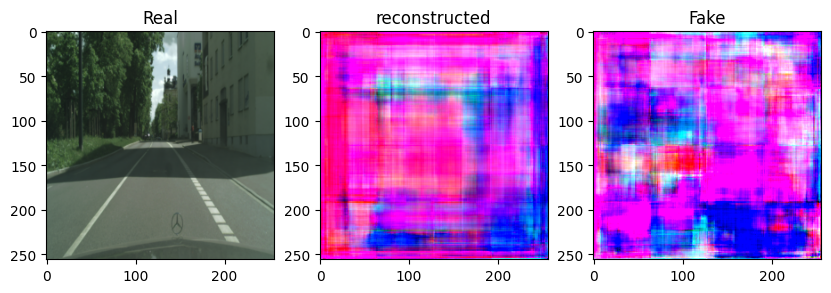

In [81]:

enc = Encoder(channels=channels,
              block_depth=enc_block_depth,
              z_dim=z_dim,
              residual=enc_residual,
              img_channels=3,
              use_norm=enc_use_norm).to(device)

gen = Generator(channels=channels,
                z_dim=z_dim,                           
                block_depth=enc_block_depth,
                residual=gen_residual,
                img_channels=3,
                use_norm=gen_use_norm).to(device)

disc = Discriminator(channels=channels,
                      block_depth=disc_block_depth,
                      residual=disc_residual,
                      img_channels=3,
                      use_norm=disc_use_norm).to(device)


enc_optim = torch.optim.Adam(enc.parameters(), lr=enc_lr)
gen_optim = torch.optim.Adam(gen.parameters(), lr=gen_lr)
disc_optim = torch.optim.Adam(disc.parameters(), lr=disc_lr)

if load_run is not None:
    enc.load_state_dict(torch.load(enc_path))
    gen.load_state_dict(torch.load(gen_path))
    disc.load_state_dict(torch.load(disc_path))




enc_optim = Adam(enc.parameters(), lr=enc_lr, betas=(0.0, 0.9))
gen_optim = Adam(gen.parameters(), lr=gen_lr, betas=(0.0, 0.9))
disc_optim = Adam(disc.parameters(), lr=disc_lr, betas=(0.0, 0.9))

train_dataset = CityscapesDataset()
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

reconstruction_loss_fn = WeightedMSELoss(weight=enc_reconstruction_loss_weight)


tensorboard_step = 0
z = torch.randn(batch_size, *z_shape).to(device)
fake = gen(z)
fake.shape

real,_ = next(iter(train_loader))
real = real.to(device)
encoded_vector = enc(real)
reconstructed_real = gen(encoded_vector)

fig, ax = plt.subplots(1, 3, figsize=(10, 5))
real = scale_for_display(real)
ax[0].imshow(real[0].cpu().detach().permute(1,2,0).numpy())
ax[0].set_title('Real')


reconstructed_real=  scale_for_display(reconstructed_real)
ax[1].imshow(reconstructed_real[0].cpu().detach().permute(1,2,0).numpy())
ax[1].set_title('reconstructed')

fake =scale_for_display(fake)
ax[2].imshow(fake[0].cpu().detach().permute(1,2,0).numpy())
ax[2].set_title('Fake')



In [ ]:
gp_loss_fn = GradientPenaltyLoss(gp_loss_weight=gp_weight_loss)
reconstruction_loss_fn = WeightedMSELoss(weight=enc_reconstruction_loss_weight)


In [ ]:
epochs = 100

for epoch in range(0,epochs):
    loop = tqdm(train_loader)
    loop.set_description(f"Epoch {epoch}/{epochs}")
    for i, (real,_) in enumerate(loop):

        real = real.to(device)

        disc_optim.zero_grad()
        disc_real = disc(real)
        disc_real_loss = -torch.mean(disc_real)

        z_noise = torch.randn(current_batch_size,*z_shape).to(device)
        with torch.no_grad():
            fake = gen(z_noise)
            fake = fake.detach()
        disc_fake = disc(fake)
        disc_fake_loss = torch.mean(disc_fake)

        disc_adv_loss = disc_real_loss + disc_fake_loss
        disc_gp_loss = gp_loss_fn(disc, real, fake)

        disc_loss = disc_adv_loss
        disc_loss.backward()
        disc_optim.step()

        gen_optim.zero_grad()
        enc_optim.zero_grad()

        z_noise = torch.randn(current_batch_size,*z_shape).to(device)
        fake = gen(z_noise)
        gen_fake = disc(fake)
        gen_adv_loss = -torch.mean(gen_fake)

        gen_loss = gen_adv_loss

        encoded_vector = enc(real)
        reconstructed = gen(encoded_vector)
        enc_reconstructed  = disc(reconstructed)
        enc_adv_loss = -torch.mean(enc_reconstructed)

        enc_reconstruction_loss = reconstruction_loss_fn(reconstructed, real)

        enc_loss = enc_adv_loss + enc_reconstruction_loss

        enc_gen_loss = gen_loss + enc_loss
        enc_gen_loss.backward()
        enc_optim.step()    
        gen_optim.step()



        # Discriminator losses
        writer.add_scalar('Discriminator_Losses/Adversarial', disc_adv_loss.item(), tensorboard_step)

        # Encoder losses
        writer.add_scalar('Encoder_Losses/Adversarial', enc_adv_loss.item(), tensorboard_step)
        writer.add_scalar('Encoder_Losses/Reconstruction', enc_reconstruction_loss.item(), tensorboard_step)
        # Generator losses
        writer.add_scalar('Generator_Losses/Adversarial', gen_adv_loss.item(), tensorboard_step)
        
        tensorboard_step += 1
        loop.set_postfix(loss_disc=disc_loss.item(),loss_gen=gen_loss.item(),enc_loss=enc_loss.item())
        if (i+1) % save_itter == 0:
            torch.save(enc.state_dict(),enc_path)
            torch.save(gen.state_dict(), gen_path)
            torch.save(disc.state_dict(),disc_path)
            epoch_root= 'epoch_{}'.format(epoch)
            os.makedirs(os.path.join(samples_path,epoch_root),exist_ok=True)
        
            with torch.no_grad():
                noise = torch.randn(current_batch_size, *z_shape).to(device)
                fake = gen(noise) 
                encoded_vector = enc(real)
                reconstructed = gen(encoded_vector)


            fake =scale_for_display(fake)
            reconstructed =scale_for_display(reconstructed)
            real =scale_for_display(real)

            imgs_to_plot = torch.cat([
                real[:4],           # Top row: Real
                reconstructed[:4],  # Middle row: Reconstructed
                fake[:4]       # Bottom row: Fake
            ], dim=0)

            # Create a grid natively on the tensσors
            grid = vutils.make_grid(imgs_to_plot, nrow=4)
            
            # 1. Save to disk (replaces plt.savefig)
            img_path = os.path.join(samples_path, epoch_root, f'{i}.png')
            vutils.save_image(grid, img_path)
            

Epoch 2/100:  88%|████████▊ | 2203/2500 [04:14<00:32,  9.05it/s, enc_loss=0.367, loss_disc=0.016, loss_gen=6.73]  

In [ ]:
z = torch.randn(batch_size, *z_shape).to(device)
fake = gen(z)
fake.shape

real,_ = next(iter(train_loader))
real = real.to(device)
encoded_vector = enc(real)
reconstructed_real = gen(encoded_vector)

fig, ax = plt.subplots(1, 3, figsize=(10, 5))
real = scale_for_display(real)
ax[0].imshow(real[0].cpu().detach().permute(1,2,0).numpy())
ax[0].set_title('Real')


reconstructed_real=  scale_for_display(reconstructed_real)
ax[1].imshow(reconstructed_real[0].cpu().detach().permute(1,2,0).numpy())
ax[1].set_title('reconstructed')

fake =scale_for_display(fake)
ax[2].imshow(fake[0].cpu().detach().permute(1,2,0).numpy())
ax[2].set_title('Fake')

